# SA - Time series txtfile creator
#### Due to memory issues, this code creates rain timeseriers from rain radar data
####  The file will be set as an input to the model during SA process

## Imports and files

In [1]:
import os
import pickle
import itertools
from collections import namedtuple
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import geopandas as gpd

import scipy.io as sio
import contextily as ctx
from shapely.geometry import Polygon, Point

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from rasterio.transform import from_origin

from swmm_api import read_inp_file, read_out_file, swmm5_run
from swmm_api.input_file import SwmmInput, section_labels as sections


## Functions

In [2]:
def radar_array_to_gdf(rain_array, xll, yll, cellsize):
    """
    Convert a 2D array representing rainfall data into a GeoDataFrame with polygon geometries.

    Parameters:
    - rain_array (numpy.ndarray): 2D array representing rainfall data.
    - xll (float): X-coordinate of the lower left corner of the grid.
    - yll (float): Y-coordinate of the lower left corner of the grid.
    - cellsize (float): Size of each cell in the grid.

    Returns:
    - radar_gdf (geopandas.GeoDataFrame): GeoDataFrame containing polygon geometries representing rainfall cells.

    This function takes a 2D array representing rainfall data and converts it into a GeoDataFrame with polygon geometries.
    Each cell in the array represents a rainfall value, and the function creates a polygon for each cell with its value
    as an attribute. The coordinate reference system is set to ITM (Israel Transverse Mercator).

    Note: The function adjusts the y-coordinate to handle the reversed north values. In the ITM coordinate system, the
    y-coordinate increases as you move south. Therefore, to align with the common representation of north-oriented grids,
    the function adjusts the y-coordinate calculation to ensure that the polygons are correctly positioned.
    """
    # Convert rainfall data to mm/hour
    rain_array = rain_array 
    
    # Calculate grid dimensions
    nrows, ncols = rain_array.shape
    # Define transformation parameters
    transform = from_origin(xll, yll, cellsize, cellsize)
    # Initialize a list to store geometries
    geometries = []
    # Iterate over rows
    for i in range(nrows):
        # Calculate y-coordinate
        y_coord = yll + (nrows - i - 1) * cellsize
        # Iterate over columns
        for j in range(ncols):
            # Get rain value
            rain_value = rain_array[i, j]
            # Calculate the coordinates of the cell
            x_min = xll + j * cellsize
            x_max = x_min + cellsize
            y_min = y_coord
            y_max = y_min - cellsize
            # Create a polygon geometry
            polygon = Polygon([(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)])
            # Append to the list of geometries
            geometries.append((rain_value, polygon))
    # Create a GeoDataFrame
    radar_gdf = gpd.GeoDataFrame(geometries, columns=['rain_value', 'geometry'])
    # Replace NaN with 0
    radar_gdf['rain_value'].fillna(0, inplace=True)
    # Set the coordinate reference system to ITM
    radar_gdf.crs = 'epsg:2039'
    
    return radar_gdf


In [3]:
def create_TimeSeriesData_txt(basins_rain_df):
    """
    Update the TimeSeriesData values of SWMM inp file by using basins_rain_df.

    Args:
        basins_rain_df (DataFrame): DataFrame where each row represents a basin, and each column represents a timestep. 
                                    The values are rain (mm) for each basin in a timestep.
    Returns:
        str: Text representation of the updated timeseries data in the specified format.
    """
    # Initialize an empty string to store the text
    timeseries_text = ''
    # Write the header
    timeseries_text += ";;Name                 Date          Time         Value     \n"
    timeseries_text += ";;------------ ----------------- ------------- -------------\n"

    # Iterate over each row in the DataFrame
    for index, row in basins_rain_df.iterrows():
        # Get the basin name
        basin_name = int(row['Basin_name'])

        # Get the first timestamp to use it as the time series name
        first_timestamp = basins_rain_df.columns[1]  # the first timestamp column
        ts_name = first_timestamp.strftime('%Y%m%d') + f"_S{basin_name}"

        # Write the data to the text
        timestamps = basins_rain_df.columns[1:]  # excluding the first column 'Basin_name'
        values = row.values[1:]  # excluding the first column 'Basin_name'
        for ts, value in zip(timestamps, values):
            date_str = ts.strftime('%m/%d/%Y')
            time_str = ts.strftime('%H:%M:%S')
            timeseries_text += f"  {ts_name}      {date_str}    {time_str}   {value:.4f}\n"
        timeseries_text += ";;------------ ----------------- ------------- -------------\n"
    
    return timeseries_text


In [4]:
def process_radar_data(rain_array_3d, raanana_basins_gdf, metadata, BIAS, radar_basin_legend_gdf):
    # First load the radar data

    rain_array_3d = rain_array_3d / 12  # Convert Units: mm/h to mm/5min
    rain_array_3d = rain_array_3d / BIAS  # Bias correction

    time_vector = radar_data['event_file'][0][0][1].ravel()
    time_vector = pd.to_datetime(time_vector - 719529, unit='D').round('1min')  # Convert the time from float to datetime and round
    time_steps = rain_array_3d.shape[-1]

    time_diff = time_vector[1:] - time_vector[:-1]
    is_5_min_interval = (time_diff == pd.Timedelta(minutes=5)).all()

    if not is_5_min_interval:
        raise ValueError("Time differences are not exactly 5 minutes. Please check the time vector.")

    radar_gdf_list = []

    for time in range(time_steps):
        rain_array_2d = rain_array_3d[:, :, time]
        radar_gdf = radar_array_to_gdf(rain_array_2d, **metadata)
        radar_intersecting_basins = gpd.sjoin(radar_gdf, raanana_basins_gdf, how="inner", predicate="intersects")
        radar_indices = radar_intersecting_basins.index.unique()
        radar_filtered_gdf = radar_gdf.loc[radar_indices]
        radar_gdf_list.append(radar_filtered_gdf['rain_value'])

    radar_poly_grid_gdf = pd.concat(radar_gdf_list, axis=1)
    radar_poly_grid_gdf.columns = time_vector

    radar_poly_grid_gdf['geometry'] = radar_gdf['geometry']
    radar_poly_grid_gdf = gpd.GeoDataFrame(radar_poly_grid_gdf, crs='epsg:2039')
    radar_poly_grid_gdf.index.name = 'radar_cell_num'

    basin_rain_columns = ['Basin_name'] + list(radar_poly_grid_gdf.columns[:])
    basins_rain_df = pd.DataFrame()
    for basin in range(1, len(raanana_basins_gdf) + 1):
        basin_df = radar_basin_legend_gdf[radar_basin_legend_gdf['Basin_name'] == basin][['Basin_name', 'pct', 'radar_cell_num']]
        basin_radar_cells_df = radar_poly_grid_gdf.loc[basin_df['radar_cell_num']]
        basin_radar_cells_df = pd.merge(basin_df, basin_radar_cells_df, on='radar_cell_num')
        weighted_avgs = []
        for col in basin_rain_columns[1:-1]:
            weighted_avg = sum(basin_radar_cells_df[col] * basin_radar_cells_df['pct'])
            weighted_avgs.append(weighted_avg)
        new_row = [basin] + weighted_avgs
        df_basin = pd.DataFrame([new_row], columns=basin_rain_columns[:-1])
        basins_rain_df = pd.concat([basins_rain_df, df_basin])
    basins_rain_df = basins_rain_df.reset_index(drop=True)
    basins_rain_df.fillna(0, inplace=True)

    resampled_dfs = []
    date = basins_rain_df.columns[1].strftime('%Y%m%d')  # Format date as YYYYMMDD
    
    return basins_rain_df


# Load files

In [5]:
# Raanana sub-basin shapefile
raanana_basins_shapfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'
raanana_basins_gdf = gpd.read_file(raanana_basins_shapfile)  # sub-basins poly
raanana_basins_gdf.drop(columns=['Shape_Area', 'Area_km2', 'Area_ha','Area_m2'], inplace = True)

# Load the storm MAT file
radar_dir = r'D:\Development\RESEARCH\Raanana\data\rain_radar\Row_radar_correct_MAT_files/'
EVENTS_AND_BIAS_L = [('20120113', 1.56),
    ('20160108', 1.24),
    ('20180125', 1.29),
    ('20191213', 0.79)]

In [6]:
## SELECT the storm event:
event_idx = 0

## Select random time slice to createlegend df
time_i = 1
## Load rain array
filename_date = EVENTS_AND_BIAS_L[event_idx][0]
rain_gauge_bias = EVENTS_AND_BIAS_L[event_idx][1]
radar_data = sio.loadmat(radar_dir + filename_date)
# Rain Data
rain_array_3d= radar_data['event_file'][0][0][0]
rain_array_2d = rain_array_3d[:, :, time_i]  # Access only one time slice
time_vector= radar_data['event_file'][0][0][1].ravel()
time_vector = pd.to_datetime(time_vector-719529, unit='D').round('1min') # Convert the time from float to datetime and round 


# Create shifted rain  timeserie txt files

In [7]:
# Directory path
directory_path = os.path.join(r"D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation", filename_date, "Rain_shift")
# Create the directory if it doesn't exist
os.makedirs(directory_path, exist_ok=True)

metadata = {
    'xll': 179000,
    'yll': 648500,
    'cellsize': 500
}

x_shifts = np.arange(-10000, 10500, 500)
y_shifts = np.arange(-20000, 20500, 500)

for x_shift in x_shifts:
    for y_shift in y_shifts:
        # Generate the filename first to check if it exists
        shift_name = f"rain_shift_x{'plus' if x_shift >= 0 else 'minus'}_{abs(x_shift)}_y{'plus' if y_shift >= 0 else 'minus'}_{abs(y_shift)}.txt"
        file_path = os.path.join(directory_path, shift_name)
        
        # Skip if file already exists
        if os.path.exists(file_path):
            print(f"File already exists, skipping: {file_path}")
            continue
            
        shifted_xll = metadata['xll'] + x_shift
        shifted_yll = metadata['yll'] + y_shift
        shifted_metadata = {
            'xll': shifted_xll,
            'yll': shifted_yll,
            'cellsize': 500
        }

        # Convert the array to a GeoDataFrame
        radar_gdf = radar_array_to_gdf(rain_array_2d, **shifted_metadata)

        # Perform spatial join to find radar cells intersecting with basins
        radar_intersecting_basins = gpd.sjoin(radar_gdf, raanana_basins_gdf, how="inner", predicate="intersects")
        
        # Create an empty DataFrame to store the results
        radar_basin_legend_gdf = pd.DataFrame(columns=['Basin_name', 'radar_cell_num', 'pct', 'basin_geometry', 'radar_geometry'])

        # Iterate over each basin in raanana_basins_gdf
        for basin_index, basin_row in raanana_basins_gdf.iterrows():
            # Get the basin name and geometry
            basin_name = basin_row['Name']
            basin_geometry = basin_row['geometry']

            # Filter radar cells intersecting with the current basin
            intersecting_radar_cells = radar_intersecting_basins[radar_intersecting_basins['index_right'] == basin_index]

            # Calculate the total area of the current basin
            basin_area = basin_geometry.area

            # Iterate over each intersecting radar cell
            for index, radar_cell in intersecting_radar_cells.iterrows():
                # Get the radar cell number and geometry
                radar_cell_num = radar_cell.name
                radar_geometry = radar_cell['geometry']

                # Check if both geometries are valid before calculating intersection
                if basin_geometry.is_valid and radar_geometry.is_valid:
                    # Find the intersection between the basin and radar cell
                    intersection = basin_geometry.intersection(radar_geometry)

                    # Check if the intersection is valid
                    if intersection.is_valid:
                        # Calculate the percentage of intersection
                        pct = (intersection.area / basin_area)  # Normalize by basin area

                        # Add the result to the DataFrame
                        radar_basin_legend_gdf = pd.concat([
                            radar_basin_legend_gdf, 
                            pd.DataFrame({
                                'Basin_name': [basin_name],
                                'radar_cell_num': [radar_cell_num],
                                'pct': [pct],
                                'basin_geometry': [basin_geometry],
                                'radar_geometry': [radar_geometry]
                            })
                        ], ignore_index=True)

        basins_rain_df = process_radar_data(rain_array_3d, raanana_basins_gdf, shifted_metadata, rain_gauge_bias, radar_basin_legend_gdf)
        
        transform_timeseries_text = create_TimeSeriesData_txt(basins_rain_df)

        # Write the file
        with open(file_path, 'w') as file:
            file.write(transform_timeseries_text)
        
        print("Text data saved to:", file_path)
        
## To visualaize un-comment it--->       
#         # Define min and max values for the color bar
#         vmin = 0  # minimum value
#         vmax = 1  # maximum value

#         # Plot the Raanana sub-basins
#         fig, ax = plt.subplots()
#         raanana_basins_gdf.plot(ax=ax, color='none', edgecolor='black')

#         # Plot the radar data
#         radar_gdf.plot(column='rain_value', cmap='Blues', legend=True, ax=ax, alpha=0.5, vmin=vmin, vmax=vmax)

#         # Define x and y axis limits
#         x_min, x_max = 180000, 195000  # Replace with your desired x-axis limits
#         y_min, y_max = 673000, 680000  # Replace with your desired y-axis limits
#         ax.set_xlim([x_min, x_max])
#         ax.set_ylim([y_min, y_max])

#         # Add legend for radar data
#         plt.legend(['Raanana Sub-basins', 'Rainfall Data'])

#         # Get the start and end times
#         time = time_vector[300].strftime("%Y-%m-%d %H:%M")


#         # Title with the time range
#         plt.title(f'Raanana Sub-basins with Radar Rainfall Data\n{time}')

#         # Add axis labels
#         plt.xlabel('Easting')
#         plt.ylabel('Northing')

#         # Show the plot
#         plt.show()

File already exists, skipping: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_10000_yminus_20000.txt
File already exists, skipping: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_10000_yminus_19500.txt
File already exists, skipping: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_10000_yminus_19000.txt
File already exists, skipping: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_10000_yminus_18500.txt
File already exists, skipping: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_10000_yminus_18000.txt
File already exists, skipping: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_10000_ymi

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_4000_yplus_17500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_4000_yplus_18000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_4000_yplus_18500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_4000_yplus_19000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_4000_yplus_19500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_4000_yplus_20000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_ra

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3500_yplus_15500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3500_yplus_16000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3500_yplus_16500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3500_yplus_17000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3500_yplus_17500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3500_yplus_18000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_ra

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3000_yplus_15500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3000_yplus_16000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3000_yplus_16500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3000_yplus_17000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3000_yplus_17500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_3000_yplus_18000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_ra

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_2500_yplus_15500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_2500_yplus_16000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_2500_yplus_16500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_2500_yplus_17000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_2500_yplus_17500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xminus_2500_yplus_18000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_ra

...

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8000_yplus_15500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8000_yplus_16000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8000_yplus_16500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8000_yplus_17000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8000_yplus_17500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8000_yplus_18000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8500_yplus_15500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8500_yplus_16000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8500_yplus_16500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8500_yplus_17000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8500_yplus_17500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_8500_yplus_18000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9000_yplus_15500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9000_yplus_16000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9000_yplus_16500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9000_yplus_17000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9000_yplus_17500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9000_yplus_18000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9500_yplus_15500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9500_yplus_16000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9500_yplus_16500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9500_yplus_17000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9500_yplus_17500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_9500_yplus_18000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA

Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_10000_yplus_15500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_10000_yplus_16000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_10000_yplus_16500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_10000_yplus_17000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_10000_yplus_17500.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation\20120113\Rain_shift\rain_shift_xplus_10000_yplus_18000.txt
Text data saved to: D:\Development\RESEARCH\Raanana\data\rain_ra

### Radar on Basin plot

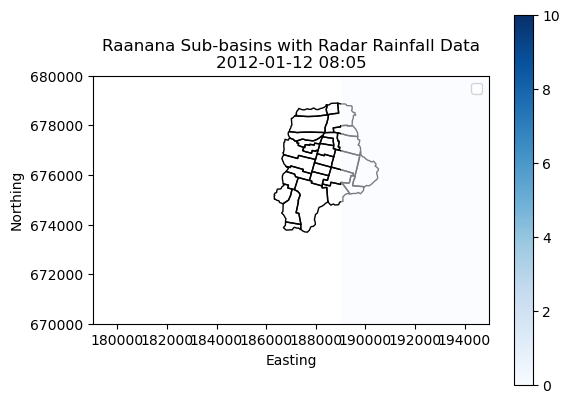

In [9]:
# Define min and max values for the color bar
vmin = 0  # minimum value
vmax = 10  # maximum value

# Plot the Raanana sub-basins
fig, ax = plt.subplots()
raanana_basins_gdf.plot(ax=ax, color='none', edgecolor='black')

# Plot the radar data
radar_gdf.plot(column='rain_value', cmap='Blues', legend=True, ax=ax, alpha=0.5, vmin=vmin, vmax=vmax)

# Define x and y axis limits
x_min, x_max = 179000, 195000  # Replace with your desired x-axis limits
y_min, y_max = 670000, 680000  # Replace with your desired y-axis limits
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])

# Add legend for radar data
plt.legend(['Raanana Sub-basins', 'Rainfall Data'])

# Get the start and end times
time = time_vector[time_i].strftime("%Y-%m-%d %H:%M")


# Title with the time range
plt.title(f'Raanana Sub-basins with Radar Rainfall Data\n{time}')

# Add axis labels
plt.xlabel('Easting')
plt.ylabel('Northing')

# Show the plot
plt.show()
